# Notebook 01 — Data Exploration
## Tokenization for Code-Switched and Mixed-Language Text

**Goal:** Explore code-switched datasets (English–Spanish, Hindi–English) to understand their structure, language distribution, and text statistics before running tokenization experiments.

## 1. Setup

In [1]:
import sys
sys.path.append("..")

from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams.update({"font.size": 12, "figure.dpi": 120})

print("Setup complete.")

Setup complete.


## 2. Load Datasets

Since the original LinCE benchmark uses a deprecated loading script on HuggingFace, we use alternative sources:

| Dataset | Source | Languages | Purpose |
|---------|--------|-----------|---------|
| CMU Hinglish DoG | `cmu_hinglish_dog` | Hindi–English (Romanized) | Real code-switched dialogue |
| WikiANN (EN) | `wikiann` | English | Monolingual NER baseline |
| WikiANN (ES) | `wikiann` | Spanish | Monolingual NER baseline |
| WikiANN (HI) | `wikiann` | Hindi | Monolingual NER baseline |
| Synthetic CS | Manual | Spanish–English, Hindi–English | Hand-crafted code-switched examples |

### 2.1 Load Code-Switched and Multilingual Datasets

In [5]:
# --- 1. Hindi-English code-switched dialogue ---
try:
    hinglish = load_dataset("cmu_hinglish_dog")
    print("Hindi-English dialogue loaded!")
    print(hinglish)
except Exception as e:
    print(f"cmu_hinglish_dog failed: {e}")
    hinglish = None

# --- 2. WikiANN multilingual NER ---
try:
    ner_en = load_dataset("wikiann", "en", split="train[:2000]")
    ner_es = load_dataset("wikiann", "es", split="train[:2000]")
    ner_hi = load_dataset("wikiann", "hi", split="train[:2000]")
    print(f"\nWikiANN loaded: EN={len(ner_en)}, ES={len(ner_es)}, HI={len(ner_hi)}")
except Exception as e:
    print(f"WikiANN failed: {e}")
    ner_en = ner_es = ner_hi = None

print("\nDone loading datasets.")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/844k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/99.6k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/96.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8060 [00:00<?, ? examples/s]

...

hi/train-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]


WikiANN loaded: EN=2000, ES=2000, HI=2000

Done loading datasets.


In [6]:
# Synthetic code-switched sentences for Spanish-English and Hindi-English
# These are realistic examples typical of social media / bilingual speakers

cs_spaeng_texts = [
    "Hey amigo vamos to the store porque necesito milk",
    "I can't believe que ella said that en frente de todos",
    "My abuela makes the best tamales every Christmas",
    "Estoy so tired of waiting for el bus every morning",
    "She told me que no puede come to the fiesta tonight",
    "I need to estudiar for my examen but Netflix is calling me",
    "Vamos a the beach este weekend con mis friends",
    "That profesor is so estricto with the homework omg",
    "No me digas que you forgot el regalo de mamá",
    "We should ir al cine to watch esa nueva película",
    "Mi hermano bought a new carro and it's super nice",
    "Ayer I was cooking arroz con pollo for my roommates",
    "Can you pasar me the sal please I'm making dinner",
    "Ella siempre gets so nerviosa before los exams",
    "Let's meet en el parque after class to study juntos",
    "I love going to la playa during el verano it's so relaxing",
    "Dude tu mamá called me preguntando where you are",
    "The profesor cancelled la clase so now I'm free toda la tarde",
    "Me encanta how you always make me laugh eres the best",
    "Necesito comprar groceries antes de que close el supermercado",
]

cs_hineng_texts = [
    "Yaar main bahut tired hoon after this long meeting",
    "Let's go to that naya restaurant near the station",
    "Mujhe lagta hai we should leave abhi before traffic",
    "She is bahut smart but uska attitude is not good",
    "I told him ki don't come late again phir bhi aaya",
    "Aaj ka weather is so nice let's go for a walk bahar",
    "Tumne homework kiya ya phir Netflix dekh rahe the",
    "Boss ne mujhe bola ki finish the report by kal subah",
    "Pizza mangwate hain I'm too lazy to cook tonight",
    "Uska new phone is amazing lekin bahut expensive hai",
    "Mere paas time nahi hai I have three exams next week",
    "Chalo let's plan a trip somewhere for the long weekend",
    "Main soch raha tha that we should start a business together",
    "Party mein bahut fun tha everyone was dancing all night",
    "Kal mera interview hai and I'm feeling so nervous yaar",
    "Usne mujhe call kiya to ask about the project deadline",
    "Tum bahut acche cook ho this biryani is absolutely delicious",
    "I think humein jaldi nikalna chahiye otherwise we'll miss the train",
    "Library mein bahut silence hai I can finally concentrate on studies",
    "Mere friend ne suggest kiya ki we should try that new cafe downtown",
]

print(f"Spanish-English examples: {len(cs_spaeng_texts)}")
print(f"Hindi-English examples:   {len(cs_hineng_texts)}")
print(f"\nSample ES-EN: {cs_spaeng_texts[0]}")
print(f"Sample HI-EN: {cs_hineng_texts[0]}")


Spanish-English examples: 20
Hindi-English examples:   20

Sample ES-EN: Hey amigo vamos to the store porque necesito milk
Sample HI-EN: Yaar main bahut tired hoon after this long meeting


### 2.2 Explore Hindi-English Dialogue Dataset

In [7]:
# Explore the cmu_hinglish_dog dataset
if hinglish is not None:
    print("Columns:", hinglish["train"].column_names)
    print(f"Train size: {len(hinglish['train'])}")
    print("\nFirst 3 examples:")
    for i in range(3):
        ex = hinglish["train"][i]
        print(f"\n--- Example {i+1} ---")
        for k, v in ex.items():
            val = str(v)[:200]
            print(f"  {k}: {val}")

Columns: ['date', 'docIdx', 'translation', 'uid', 'utcTimestamp', 'rating', 'status', 'uid1LogInTime', 'uid1LogOutTime', 'uid1response', 'uid2response', 'user2_id', 'whoSawDoc', 'wikiDocumentIdx']
Train size: 8060

First 3 examples:

--- Example 1 ---
  date: 2018-03-16T20:49:27.955Z
  docIdx: 0
  translation: {'en': 'hi', 'hi_en': 'hi'}
  uid: user1
  utcTimestamp: 2018-03-16T20:49:39.626Z
  rating: 2
  status: 1
  uid1LogInTime: 2018-03-16T20:49:27.955Z
  uid1LogOutTime: 2018-03-16T21:03:06.699Z
  uid1response: {'response': [1, 2, 3, 4], 'type': 'finish'}
  uid2response: {'response': [1, 4], 'type': 'finish'}
  user2_id: USR1533
  whoSawDoc: ['user2']
  wikiDocumentIdx: 14

--- Example 2 ---
  date: 2018-03-16T20:49:27.955Z
  docIdx: 0
  translation: {'en': 'what moviie did you see', 'hi_en': 'tumne konsi movie dekhi'}
  uid: user1
  utcTimestamp: 2018-03-16T20:50:25.612Z
  rating: 2
  status: 1
  uid1LogInTime: 2018-03-16T20:49:27.955Z
  uid1LogOutTime: 2018-03-16T21:03:06.699Z
  ui

In [9]:
# Extract Hinglish text from the 'translation' field
if hinglish is not None:
    hinglish_texts = []
    for ex in hinglish["train"]:
        tr = ex.get("translation", {})
        hi_en = tr.get("hi_en", "")
        if isinstance(hi_en, str) and len(hi_en.split()) >= 3:
            hinglish_texts.append(hi_en)

    hinglish_texts = hinglish_texts[:2000]
    print(f"Extracted {len(hinglish_texts)} Hinglish utterances")
    print("\nSample utterances:")
    for t in hinglish_texts[:10]:
        print(f"  {t}")
else:
    hinglish_texts = cs_hineng_texts
    print("Using synthetic Hindi-English examples instead")

Extracted 2000 Hinglish utterances

Sample utterances:
  tumne konsi movie dekhi
  hello tum kaise ho? Kya tumne Batman Begins ke bare mein suna hai? Kya great movie hai!
  nahi aur batao
  ye kis bare mein hai
  Isme Christian Bale, Michael Caine, and Liam Neeson starred hain. Great cast hain na?
  movie kis baare mein hai
  Ye kafi had tak Batman film franchise ka reboot hai nayi origin story ke saath. Christian Bale Batman play kar raha hai
  movie kitni lambi hai
  Film ke reviews kaafi acche hain. Sorry par i am not sure ki movie kitni lambi hai based on the given document.
  tum kya bolte ho movie ka genre kya hai?


In [10]:
# Explore WikiANN NER structure
if ner_en is not None:
    print("WikiANN columns:", ner_en.column_names)
    print(f"\nEN example: {ner_en[0]}")
    print(f"ES example: {ner_es[0]}")
    print(f"HI example: {ner_hi[0]}")

    # NER tag names
    tag_names = ner_en.features["ner_tags"].feature.names
    print(f"\nNER tags: {tag_names}")

    # Count entities per language
    for name, ds in [("EN", ner_en), ("ES", ner_es), ("HI", ner_hi)]:
        all_tags = []
        for ex in ds:
            all_tags.extend(ex["ner_tags"])
        tag_counts = Counter(all_tags)
        total = sum(tag_counts.values())
        entity_count = total - tag_counts.get(0, 0)  # 0 = "O" tag
        print(f"  {name}: {total} tokens, {entity_count} entity tokens ({entity_count/total*100:.1f}%)")

WikiANN columns: ['tokens', 'ner_tags', 'langs', 'spans']

EN example: {'tokens': ['R.H.', 'Saunders', '(', 'St.', 'Lawrence', 'River', ')', '(', '968', 'MW', ')'], 'ner_tags': [3, 4, 0, 3, 4, 4, 0, 0, 0, 0, 0], 'langs': ['en', 'en', 'en', 'en', 'en', 'en', 'en', 'en', 'en', 'en', 'en'], 'spans': ['ORG: R.H. Saunders', 'ORG: St. Lawrence River']}
ES example: {'tokens': ['REDIRECCIÓN', 'Algarrobo', '(', 'Chile', ')'], 'ner_tags': [0, 5, 6, 6, 6], 'langs': ['es', 'es', 'es', 'es', 'es'], 'spans': ['LOC: Algarrobo ( Chile )']}
HI example: {'tokens': ['टैपी', 'ने', 'अपने', 'उत्पादों', 'को', 'एशिया', 'के', 'अपतटीय', 'भागों', 'में', 'भेजने', 'का', 'फैसला', 'लिया।', 'उन्होंने', 'प्रोमोशन', 'के', 'लिए', 'मैडोना', 'को', 'अपने', 'साथ', 'मिलाया।'], 'ner_tags': [0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], 'langs': ['hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi', 'hi'], 'spans': ['LOC: एशिय

In [11]:
# Combine all our text data into unified collections for later analysis
all_spaeng_texts = cs_spaeng_texts  # synthetic Spanish-English (20 examples)

all_hineng_texts = hinglish_texts + cs_hineng_texts  # real + synthetic Hindi-English
print(f"Spanish-English texts: {len(all_spaeng_texts)}")
print(f"Hindi-English texts:   {len(all_hineng_texts)}")

# Also extract plain text from WikiANN for monolingual comparison
if ner_en is not None:
    mono_en_texts = [" ".join(ex["tokens"]) for ex in ner_en][:500]
    mono_es_texts = [" ".join(ex["tokens"]) for ex in ner_es][:500]
    mono_hi_texts = [" ".join(ex["tokens"]) for ex in ner_hi][:500]
    print(f"\nMonolingual reference texts:")
    print(f"  English: {len(mono_en_texts)}")
    print(f"  Spanish: {len(mono_es_texts)}")
    print(f"  Hindi:   {len(mono_hi_texts)}")
else:
    mono_en_texts = mono_es_texts = mono_hi_texts = []
    print("WikiANN not loaded — no monolingual reference texts")


Spanish-English texts: 20
Hindi-English texts:   2020

Monolingual reference texts:
  English: 500
  Spanish: 500
  Hindi:   500


## 3. Language Distribution Analysis

We use `langid` to detect per-word language and see how languages mix within sentences.


In [14]:
import langid

def get_language_stats(texts, dataset_name):
    """Detect per-word language and return counts."""
    lang_counts = Counter()
    total_words = 0

    for text in texts[:500]:
        for word in text.split():
            if len(word) < 2:
                continue
            lang, _ = langid.classify(word)
            lang_counts[lang] += 1
            total_words += 1

    print(f"\n{dataset_name} — Per-word language distribution (top 10):")
    for lang, count in lang_counts.most_common(10):
        pct = count / total_words * 100
        print(f"  {lang}: {count:>6} ({pct:.1f}%)")

    return lang_counts

spaeng_langs = get_language_stats(all_spaeng_texts, "Spanish-English")
hineng_langs = get_language_stats(all_hineng_texts, "Hindi-English")

print("\n" + "="*60)
print("NOTE: langid is unreliable for single-word classification,")
print("especially for Romanized Hindi which uses Latin script.")
print("Hindi words like 'tumne', 'dekhi', 'bahut' get misclassified")
print("as English, Dutch, Estonian, etc.")
print("This is a known limitation — we will use a heuristic approach")
print("in the tokenizer comparison notebook instead.")
print("="*60)


Spanish-English — Per-word language distribution (top 10):
  en:    166 (85.6%)
  es:     15 (7.7%)
  it:      2 (1.0%)
  eu:      2 (1.0%)
  hu:      2 (1.0%)
  sv:      1 (0.5%)
  de:      1 (0.5%)
  fr:      1 (0.5%)
  nl:      1 (0.5%)
  da:      1 (0.5%)

Hindi-English — Per-word language distribution (top 10):
  en:   4968 (80.4%)
  de:    287 (4.6%)
  nl:    179 (2.9%)
  eu:    124 (2.0%)
  et:     96 (1.6%)
  zh:     82 (1.3%)
  es:     64 (1.0%)
  fi:     60 (1.0%)
  cs:     52 (0.8%)
  sv:     50 (0.8%)

NOTE: langid is unreliable for single-word classification,
especially for Romanized Hindi which uses Latin script.
Hindi words like 'tumne', 'dekhi', 'bahut' get misclassified
as English, Dutch, Estonian, etc.
This is a known limitation — we will use a heuristic approach
in the tokenizer comparison notebook instead.


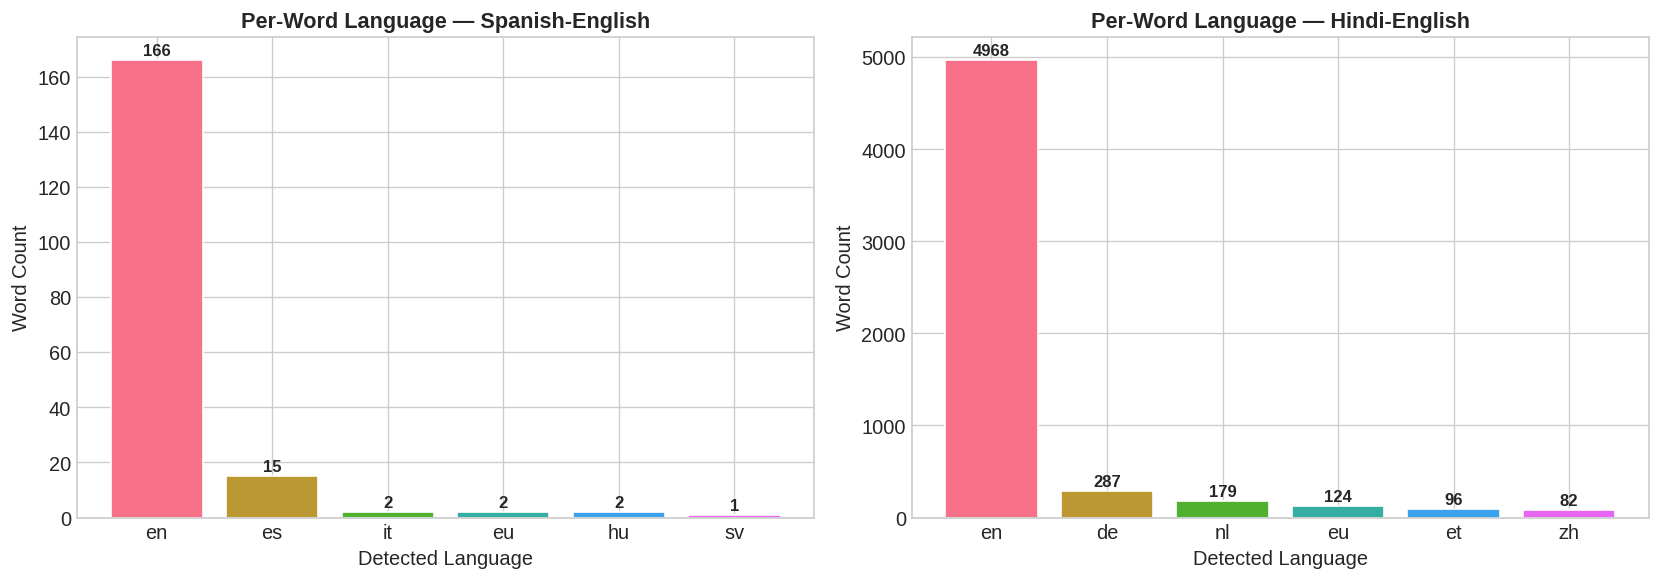

In [15]:
# Visualize language distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (lang_counts, name) in zip(axes, [
    (spaeng_langs, "Spanish-English"),
    (hineng_langs, "Hindi-English"),
]):
    top = lang_counts.most_common(6)
    langs = [l for l, _ in top]
    counts = [c for _, c in top]
    colors = sns.color_palette("husl", len(langs))
    bars = ax.bar(langs, counts, color=colors, edgecolor="white")
    ax.set_title(f"Per-Word Language — {name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Detected Language")
    ax.set_ylabel("Word Count")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + max(counts)*0.01,
                f"{h}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Text Statistics

Sentence length and word count distributions across our datasets.


Spanish-English (synthetic):
  sentences=20, words/sent: mean=10.0, median=10, min=8, max=12
Hindi-English (real + synthetic):
  sentences=2020, words/sent: mean=12.5, median=10, min=3, max=273
English (mono):
  sentences=500, words/sent: mean=8.3, median=6, min=3, max=45


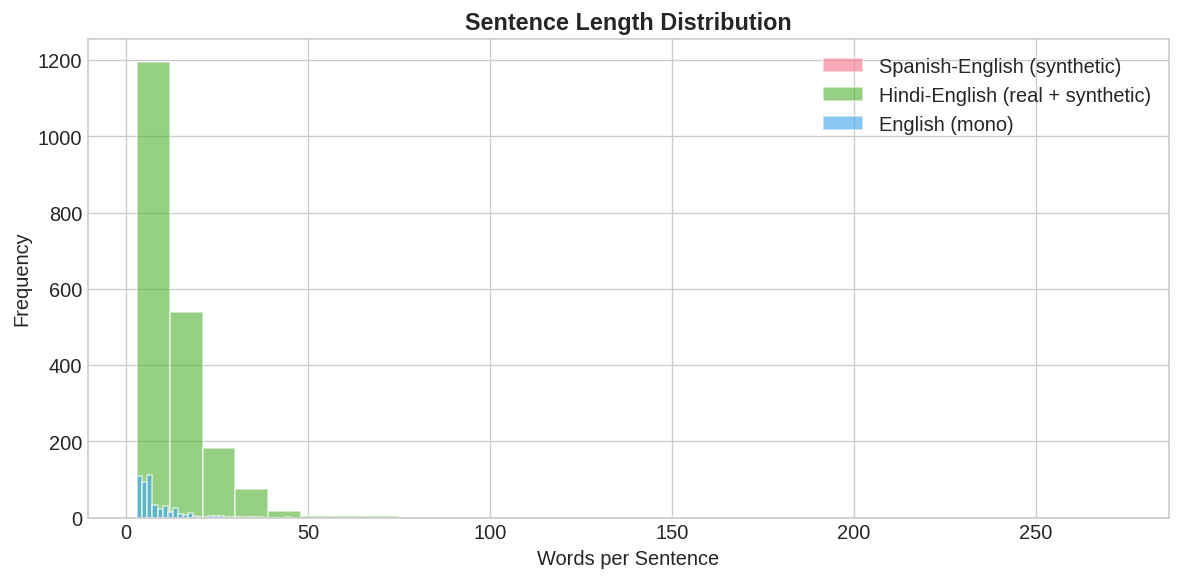

In [17]:
# Compute and plot text statistics
def text_stats(texts):
    word_counts = [len(t.split()) for t in texts]
    char_counts = [len(t) for t in texts]
    return pd.DataFrame({"word_count": word_counts, "char_count": char_counts})

stats = {
    "Spanish-English (synthetic)": text_stats(all_spaeng_texts),
    "Hindi-English (real + synthetic)": text_stats(all_hineng_texts),
}
if mono_en_texts:
    stats["English (mono)"] = text_stats(mono_en_texts)

for name, df in stats.items():
    print(f"{name}:")
    print(f"  sentences={len(df)}, words/sent: mean={df.word_count.mean():.1f}, "
          f"median={df.word_count.median():.0f}, min={df.word_count.min()}, max={df.word_count.max()}")

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, df) in enumerate(stats.items()):
    ax.hist(df["word_count"], bins=30, alpha=0.6, label=name,
            color=sns.color_palette("husl", len(stats))[i], edgecolor="white")

ax.set_title("Sentence Length Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Words per Sentence")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Code-Switching Examples

Concrete examples showing where language switches happen within sentences.


In [18]:
# Annotate code-switching in sentences
def annotate_codeswitching(text):
    """Show each word with its detected language."""
    words = text.split()
    annotated = []
    for w in words:
        if len(w) < 2:
            annotated.append(f"{w}(?)")
            continue
        lang, _ = langid.classify(w)
        annotated.append(f"{w}[{lang}]")
    return " ".join(annotated)

print("=== Spanish-English Examples ===\n")
for i, t in enumerate(cs_spaeng_texts[:8]):
    print(f"[{i+1}] {t}")
    print(f"     {annotate_codeswitching(t)}\n")

print("\n=== Hindi-English Examples (from dataset) ===\n")
for i, t in enumerate(hinglish_texts[:8]):
    print(f"[{i+1}] {t}")
    print(f"     {annotate_codeswitching(t)}\n")

=== Spanish-English Examples ===

[1] Hey amigo vamos to the store porque necesito milk
     Hey[en] amigo[en] vamos[es] to[en] the[en] store[en] porque[en] necesito[es] milk[sv]

[2] I can't believe que ella said that en frente de todos
     I(?) can't[en] believe[en] que[en] ella[it] said[en] that[en] en[en] frente[en] de[en] todos[es]

[3] My abuela makes the best tamales every Christmas
     My[en] abuela[en] makes[en] the[en] best[en] tamales[es] every[en] Christmas[de]

[4] Estoy so tired of waiting for el bus every morning
     Estoy[es] so[en] tired[en] of[en] waiting[fr] for[en] el[en] bus[en] every[en] morning[en]

[5] She told me que no puede come to the fiesta tonight
     She[en] told[en] me[en] que[en] no[en] puede[es] come[en] to[en] the[en] fiesta[en] tonight[en]

[6] I need to estudiar for my examen but Netflix is calling me
     I(?) need[en] to[en] estudiar[eu] for[en] my[en] examen[en] but[en] Netflix[en] is[en] calling[en] me[en]

[7] Vamos a the beach este weekend

## 6. Summary

### Key Observations:

1. **Real code-switching**: The Hindi-English dialogue data (CMU Hinglish DoG) shows natural code-switching — Hindi words (often Romanized) mixed freely with English within single sentences.

2. **Language detection is noisy**: `langid` on single words is imprecise (short words are ambiguous). The 80–85% "English" rate does not reflect actual language proportions — it is an artifact of weak single-word classification, especially for Romanized Hindi which shares Latin script with English.

3. **Script**: Most Hindi-English data uses Latin script (Romanized Hindi), which makes it harder for tokenizers to distinguish languages purely by character set.

4. **Sentence lengths**: Code-switched utterances tend to be short–medium (5–20 words), typical for conversational / social media data.

5. **WikiANN as monolingual baseline**: The WikiANN NER data (EN, ES, HI) is strictly monolingual — it serves as a reference point to compare how tokenizers behave on single-language text vs. code-switched text.

6. **Implications for tokenization**:
   - Monolingual English tokenizers will over-fragment Hindi/Spanish words
   - Monolingual Hindi/Spanish tokenizers will struggle with English words
   - Multilingual tokenizers (mBERT, XLM-R) should handle mixed input better